In [1]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [2]:
!pip install torchtext==0.6.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 2.7 MB/s eta 0:00:00


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchtext.datasets import Multi30k
from torchtext.data import Field, BucketIterator

import spacy
import random
import math
import time

# Download Tokenizers

In [4]:
!python -m spacy download en_core_web_sm
!python -m spacy download de_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 77.9 MB/s eta 0:00:0000:010:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 68.7 MB/s eta 0:00:0000:010:01
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


# Load Tokenizers

In [5]:
import spacy

spacy_en = spacy.load("en_core_web_sm")
spacy_de = spacy.load("de_core_news_sm")

# Build Tokenizer Functions

In [6]:
def tokenize_de(text):
    return [tok.text.lower() for tok in spacy_de.tokenizer(text)]

def tokenize_en(text):
    return [tok.text.lower() for tok in spacy_en.tokenizer(text)]

# Create Fields

In [7]:
SRC = Field(
    tokenize=tokenize_de,
    init_token="<sos>",
    eos_token="<eos>",
    lower=True
)

TRG = Field(
    tokenize=tokenize_en,
    init_token="<sos>",
    eos_token="<eos>",
    lower=True
)

# Download Dataset Manualy

In [8]:
!wget https://raw.githubusercontent.com/multi30k/dataset/master/data/task1/raw/train.en.gz
!wget https://raw.githubusercontent.com/multi30k/dataset/master/data/task1/raw/train.de.gz

!wget https://raw.githubusercontent.com/multi30k/dataset/master/data/task1/raw/val.en.gz
!wget https://raw.githubusercontent.com/multi30k/dataset/master/data/task1/raw/val.de.gz

!wget https://raw.githubusercontent.com/multi30k/dataset/master/data/task1/raw/test_2016_flickr.en.gz
!wget https://raw.githubusercontent.com/multi30k/dataset/master/data/task1/raw/test_2016_flickr.de.gz

--2026-05-02 22:53:25--  https://raw.githubusercontent.com/multi30k/dataset/master/data/task1/raw/train.en.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 568929 (556K) [application/octet-stream]
Saving to: ‘train.en.gz’

train.en.gz         100%[===================>] 555.59K  --.-KB/s    in 0.04s   

2026-05-02 22:53:25 (13.4 MB/s) - ‘train.en.gz’ saved [568929/568929]

--2026-05-02 22:53:25--  https://raw.githubusercontent.com/multi30k/dataset/master/data/task1/raw/train.de.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6

# Unzip Files

In [9]:
!gunzip train.en.gz
!gunzip train.de.gz

!gunzip val.en.gz
!gunzip val.de.gz

!gunzip test_2016_flickr.en.gz
!gunzip test_2016_flickr.de.gz

# Rename Test Files

In [10]:
!mv val.en valid.en
!mv val.de valid.de

!mv test_2016_flickr.en test.en
!mv test_2016_flickr.de test.de

# Load Dataset MANUALLY

In [11]:
from torchtext.data import TabularDataset

In [12]:
from torchtext.datasets.translation import TranslationDataset

In [13]:
train_data = TranslationDataset(
    path='train',
    exts=('.de', '.en'),
    fields=(SRC, TRG)
)

valid_data = TranslationDataset(
    path='valid',
    exts=('.de', '.en'),
    fields=(SRC, TRG)
)

test_data = TranslationDataset(
    path='test',
    exts=('.de', '.en'),
    fields=(SRC, TRG)
)

# verify Variable

In [14]:
print(train_data)
print(valid_data)
print(test_data)

# Build Vocabulary

In [15]:
SRC.build_vocab(train_data, min_freq=2)
TRG.build_vocab(train_data, min_freq=2)

# Create DataLoader

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [17]:
BATCH_SIZE = 64

train_iterator, valid_iterator, test_iterator = BucketIterator.splits(
    (train_data, valid_data, test_data),
    batch_size=BATCH_SIZE,
    device=device
)

# Encoder Code

In [18]:
class Encoder(nn.Module):

    def __init__(self,
                 input_dim,
                 emb_dim,
                 enc_hidden_dim,
                 dec_hidden_dim,
                 dropout):

        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)

        self.rnn = nn.GRU(
            emb_dim,
            enc_hidden_dim,
            bidirectional=True
        )

        self.fc = nn.Linear(enc_hidden_dim * 2, dec_hidden_dim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, src):

        embedded = self.dropout(self.embedding(src))

        outputs, hidden = self.rnn(embedded)

        hidden = torch.tanh(
            self.fc(
                torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
            )
        )

        return outputs, hidden

# Attention Class

In [19]:
class Attention(nn.Module):

    def __init__(self,
                 enc_hidden_dim,
                 dec_hidden_dim):

        super().__init__()

        self.attn = nn.Linear(
            (enc_hidden_dim * 2) + dec_hidden_dim,
            dec_hidden_dim
        )

        self.v = nn.Linear(dec_hidden_dim, 1, bias=False)

    def forward(self,
                hidden,
                encoder_outputs):

        # hidden shape:
        # [batch size, dec hidden dim]

        # encoder_outputs shape:
        # [src len, batch size, enc hidden dim * 2]

        batch_size = encoder_outputs.shape[1]

        src_len = encoder_outputs.shape[0]

        # repeat decoder hidden state
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)

        # reshape encoder outputs
        encoder_outputs = encoder_outputs.permute(1, 0, 2)

        # hidden:
        # [batch size, src len, dec hidden dim]

        # encoder_outputs:
        # [batch size, src len, enc hidden dim * 2]

        energy = torch.tanh(
            self.attn(
                torch.cat((hidden, encoder_outputs), dim=2)
            )
        )

        # energy shape:
        # [batch size, src len, dec hidden dim]

        attention = self.v(energy).squeeze(2)

        # attention shape:
        # [batch size, src len]

        return torch.softmax(attention, dim=1)

# Test Attention Layer

In [20]:
INPUT_DIM = len(SRC.vocab)
OUTPUT_DIM = len(TRG.vocab)

ENC_EMB_DIM = 256
DEC_EMB_DIM = 256

ENC_HIDDEN_DIM = 512
DEC_HIDDEN_DIM = 512

ENC_DROPOUT = 0.5
DEC_DROPOUT = 0.5

In [21]:
attn = Attention(
    ENC_HIDDEN_DIM,
    DEC_HIDDEN_DIM
)

In [22]:
enc = Encoder(
    INPUT_DIM,
    ENC_EMB_DIM,
    ENC_HIDDEN_DIM,
    DEC_HIDDEN_DIM,
    ENC_DROPOUT
)

In [26]:
enc = enc.to(device)

In [66]:
attn = attn.to(device)

In [31]:
src = next(iter(train_iterator)).src

encoder_outputs, hidden = enc(src)

attention_weights = attn(hidden, encoder_outputs)

print(attention_weights.shape)

torch.Size([64, 25])


# Decoder class

In [43]:
class Decoder(nn.Module):

    def __init__(self,
                 output_dim,
                 emb_dim,
                 enc_hidden_dim,
                 dec_hidden_dim,
                 dropout,
                 attention):

        super().__init__()

        self.output_dim = output_dim
        self.attention = attention

        self.embedding = nn.Embedding(output_dim, emb_dim)

        self.rnn = nn.GRU(
            (enc_hidden_dim * 2) + emb_dim,
            dec_hidden_dim
        )

        self.fc_out = nn.Linear(
            (enc_hidden_dim * 2)
            + dec_hidden_dim
            + emb_dim,
            output_dim
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self,
                input,
                hidden,
                encoder_outputs):

        # input shape:
        # [batch size]

        input = input.unsqueeze(0)

        # input shape:
        # [1, batch size]

        embedded = self.dropout(
            self.embedding(input)
        )

        # embedded shape:
        # [1, batch size, emb dim]

        attention = self.attention(
            hidden,
            encoder_outputs
        )

        # attention shape:
        # [batch size, src len]

        attention = attention.unsqueeze(1)

        # attention shape:
        # [batch size, 1, src len]

        encoder_outputs = encoder_outputs.permute(1, 0, 2)

        # encoder_outputs:
        # [batch size, src len, enc hidden dim * 2]

        weighted = torch.bmm(
            attention,
            encoder_outputs
        )

        # weighted shape:
        # [batch size, 1, enc hidden dim * 2]

        weighted = weighted.permute(1, 0, 2)

        # weighted shape:
        # [1, batch size, enc hidden dim * 2]

        rnn_input = torch.cat(
            (embedded, weighted),
            dim=2
        )

        # rnn_input shape:
        # [1, batch size, emb dim + enc hidden dim * 2]

        output, hidden = self.rnn(
            rnn_input,
            hidden.unsqueeze(0)
        )

        # output shape:
        # [1, batch size, dec hidden dim]

        # hidden shape:
        # [1, batch size, dec hidden dim]

        embedded = embedded.squeeze(0)
        output = output.squeeze(0)
        weighted = weighted.squeeze(0)

        prediction = self.fc_out(
            torch.cat(
                (output, weighted, embedded),
                dim=1
            )
        )

        # prediction shape:
        # [batch size, output dim]

        return prediction, hidden.squeeze(0), attention.squeeze(1)

# Build Decoder

In [46]:
dec = Decoder(
    OUTPUT_DIM,
    DEC_EMB_DIM,
    ENC_HIDDEN_DIM,
    DEC_HIDDEN_DIM,
    DEC_DROPOUT,
    attn
)

In [69]:
dec = dec.to(device)

# Test Decoder

In [49]:
batch = next(iter(train_iterator))

src = batch.src

In [52]:
encoder_outputs, hidden = enc(src)

In [56]:
input = batch.trg[0]

In [75]:
prediction, hidden, attention = dec(
    input,
    hidden,
    encoder_outputs
)

In [77]:
print(prediction.shape)
print(hidden.shape)
print(attention.shape)

torch.Size([64, 5893])
torch.Size([64, 512])
torch.Size([64, 25])


# Seq2Seq Class

In [81]:
class Seq2Seq(nn.Module):

    def __init__(self,
                 encoder,
                 decoder,
                 device):

        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self,
                src,
                trg,
                teacher_forcing_ratio=0.5):

        # src shape:
        # [src len, batch size]

        # trg shape:
        # [trg len, batch size]

        batch_size = trg.shape[1]

        trg_len = trg.shape[0]

        trg_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(
            trg_len,
            batch_size,
            trg_vocab_size
        ).to(self.device)

        # encoder outputs
        encoder_outputs, hidden = self.encoder(src)

        # first input to decoder
        input = trg[0]

        for t in range(1, trg_len):

            output, hidden, attention = self.decoder(
                input,
                hidden,
                encoder_outputs
            )

            outputs[t] = output

            teacher_force = random.random() < teacher_forcing_ratio

            top1 = output.argmax(1)

            input = trg[t] if teacher_force else top1

        return outputs

# Build Full Model

In [86]:
model = Seq2Seq(
    enc,
    dec,
    device
).to(device)

# Count Parameters

In [88]:
def count_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 20,518,405 trainable parameters


# Initialize Weights

In [90]:
def init_weights(m):

    for name, param in m.named_parameters():

        nn.init.normal_(param.data, mean=0, std=0.01)

In [94]:
model.apply(init_weights)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(7853, 256)
    (rnn): GRU(256, 512, bidirectional=True)
    (fc): Linear(in_features=1024, out_features=512, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (decoder): Decoder(
    (attention): Attention(
      (attn): Linear(in_features=1536, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(5893, 256)
    (rnn): GRU(1280, 512)
    (fc_out): Linear(in_features=1792, out_features=5893, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
)

# Optimizer

In [97]:
optimizer = optim.Adam(model.parameters())

# Loss Function

In [102]:
TRG_PAD_IDX = TRG.vocab.stoi[TRG.pad_token]

criterion = nn.CrossEntropyLoss(
    ignore_index=TRG_PAD_IDX
)

# Forward Pass Test

In [105]:
batch = next(iter(train_iterator))

src = batch.src
trg = batch.trg

output = model(src, trg)

In [108]:
print(output.shape)

torch.Size([31, 64, 5893])


# Training Function

In [111]:
def train(model,
          iterator,
          optimizer,
          criterion,
          clip):

    model.train()

    epoch_loss = 0

    for i, batch in enumerate(iterator):

        src = batch.src
        trg = batch.trg

        optimizer.zero_grad()

        output = model(src, trg)

        # output shape:
        # [trg len, batch size, output dim]

        output_dim = output.shape[-1]

        output = output[1:].view(-1, output_dim)

        trg = trg[1:].view(-1)

        # output:
        # [(trg len - 1) * batch size, output dim]

        # trg:
        # [(trg len - 1) * batch size]

        loss = criterion(output, trg)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            clip
        )

        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(iterator)

# Evaluation Function

In [114]:
def evaluate(model,
             iterator,
             criterion):

    model.eval()

    epoch_loss = 0

    with torch.no_grad():

        for i, batch in enumerate(iterator):

            src = batch.src
            trg = batch.trg

            output = model(
                src,
                trg,
                0
            )

            output_dim = output.shape[-1]

            output = output[1:].view(-1, output_dim)

            trg = trg[1:].view(-1)

            loss = criterion(output, trg)

            epoch_loss += loss.item()

    return epoch_loss / len(iterator)

# Epoch Timer

In [117]:
def epoch_time(start_time,
               end_time):

    elapsed_time = end_time - start_time

    elapsed_mins = int(elapsed_time / 60)

    elapsed_secs = int(
        elapsed_time - (elapsed_mins * 60)
    )

    return elapsed_mins, elapsed_secs

# Start Training

In [124]:
N_EPOCHS = 10

CLIP = 1

# Best Validation Loss

In [133]:
best_valid_loss = float('inf')

# Full Training Loop

In [134]:
for epoch in range(N_EPOCHS):

    start_time = time.time()

    train_loss = train(
        model,
        train_iterator,
        optimizer,
        criterion,
        CLIP
    )

    valid_loss = evaluate(
        model,
        valid_iterator,
        criterion
    )

    end_time = time.time()

    epoch_mins, epoch_secs = epoch_time(
        start_time,
        end_time
    )

    if valid_loss < best_valid_loss:

        best_valid_loss = valid_loss

        torch.save(
            model.state_dict(),
            'best-model.pt'
        )

    print(f'Epoch: {epoch+1:02}')
    print(f'Time: {epoch_mins}m {epoch_secs}s')

    print(f'Train Loss: {train_loss:.3f}')

    print(f'Val Loss: {valid_loss:.3f}')

Epoch: 01
Time: 1m 34s
Train Loss: 4.588
Val Loss: 4.318
Epoch: 02
Time: 1m 29s
Train Loss: 3.405
Val Loss: 3.584
Epoch: 03
Time: 1m 29s
Train Loss: 2.730
Val Loss: 3.328
Epoch: 04
Time: 1m 31s
Train Loss: 2.337
Val Loss: 3.214
Epoch: 05
Time: 1m 30s
Train Loss: 2.015
Val Loss: 3.196
Epoch: 06
Time: 1m 28s
Train Loss: 1.786
Val Loss: 3.234
Epoch: 07
Time: 1m 28s
Train Loss: 1.589
Val Loss: 3.293
Epoch: 08
Time: 1m 28s
Train Loss: 1.431
Val Loss: 3.377
Epoch: 09
Time: 1m 28s
Train Loss: 1.336
Val Loss: 3.334
Epoch: 10
Time: 1m 28s
Train Loss: 1.233
Val Loss: 3.464


# Perplexity

In [137]:
import math

print(f'Perplexity: {math.exp(valid_loss):7.3f}')

Perplexity:  31.947


# Load Best Model

In [142]:
model.load_state_dict(
    torch.load('best-model.pt')
)

<All keys matched successfully>

# Translation Function

In [148]:
def translate_sentence(sentence,
                       src_field,
                       trg_field,
                       model,
                       device,
                       max_len=50):

    model.eval()

    if isinstance(sentence, str):

        tokens = [token.text.lower()
                  for token in spacy_de(sentence)]

    else:
        tokens = [token.lower()
                  for token in sentence]

    tokens = [src_field.init_token] + tokens + [src_field.eos_token]

    src_indexes = [
        src_field.vocab.stoi[token]
        for token in tokens
    ]

    src_tensor = torch.LongTensor(src_indexes)\
        .unsqueeze(1)\
        .to(device)

    with torch.no_grad():

        encoder_outputs, hidden = model.encoder(src_tensor)

    trg_indexes = [
        trg_field.vocab.stoi[trg_field.init_token]
    ]

    attentions = torch.zeros(
        max_len,
        1,
        len(src_indexes)
    ).to(device)

    for i in range(max_len):

        trg_tensor = torch.LongTensor(
            [trg_indexes[-1]]
        ).to(device)

        with torch.no_grad():

            output, hidden, attention = model.decoder(
                trg_tensor,
                hidden,
                encoder_outputs
            )

        attentions[i] = attention

        pred_token = output.argmax(1).item()

        trg_indexes.append(pred_token)

        if pred_token == trg_field.vocab.stoi[trg_field.eos_token]:
            break

    trg_tokens = [
        trg_field.vocab.itos[i]
        for i in trg_indexes
    ]

    return trg_tokens[1:], attentions[:len(trg_tokens)-1]

# Test Translation

In [151]:
example_idx = 8

src = vars(test_data.examples[example_idx])['src']
trg = vars(test_data.examples[example_idx])['trg']

print(f'src = {src}')
print(f'trg = {trg}')

src = ['ein', 'typ', 'arbeitet', 'an', 'einem', 'gebäude', '.']
trg = ['a', 'guy', 'works', 'on', 'a', 'building', '.']


In [154]:
translation, attention = translate_sentence(
    src,
    SRC,
    TRG,
    model,
    device
)

print(f'predicted trg = {translation}')

predicted trg = ['a', 'guy', 'is', 'working', 'on', 'a', 'building', '.', '<eos>']


# Attention Visualization

# Install matplotlib

In [166]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Visualization Function

In [169]:
def display_attention(sentence,
                      translation,
                      attention):

    fig = plt.figure(figsize=(10,10))

    ax = fig.add_subplot(111)

    attention = attention.squeeze(1).cpu().detach().numpy()

    cax = ax.matshow(attention, cmap='bone')

    ax.tick_params(labelsize=12)

    ax.set_xticklabels(
        [''] + sentence + ['<eos>'],
        rotation=45
    )

    ax.set_yticklabels(
        [''] + translation
    )

    ax.xaxis.set_major_locator(
        ticker.MultipleLocator(1)
    )

    ax.yaxis.set_major_locator(
        ticker.MultipleLocator(1)
    )

    plt.show()

# Show Attention Heatmap

/tmp/ipykernel_57/2326252179.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/tmp/ipykernel_57/2326252179.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(


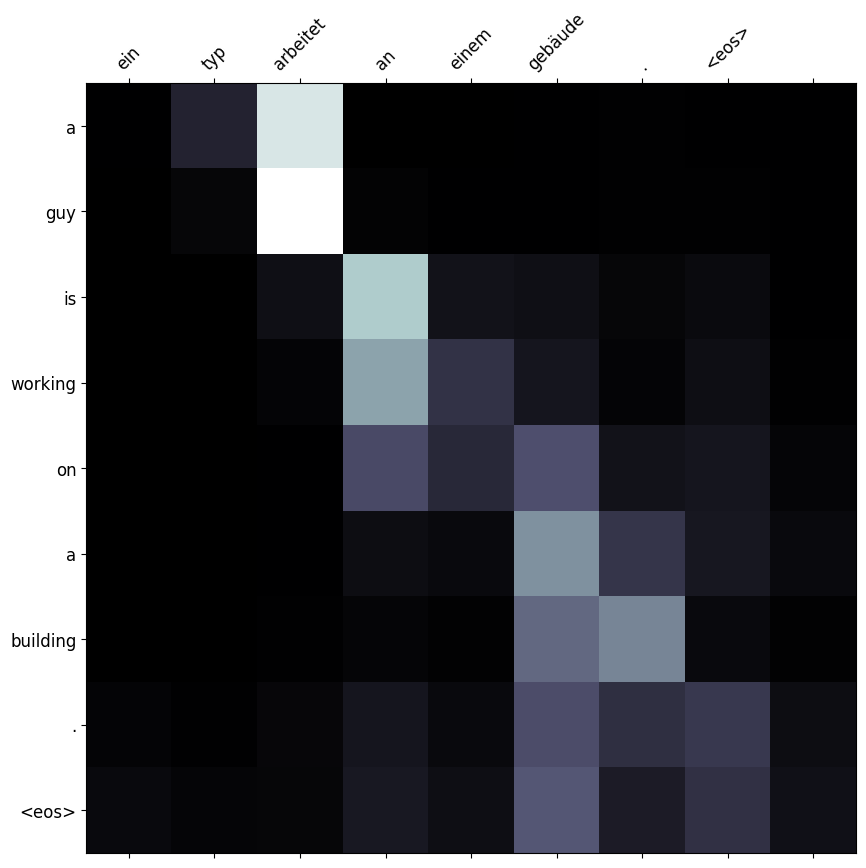

In [177]:
display_attention(
    src,
    translation,
    attention
)